# Load HCP parcellated task data
## (version with Behavioural Data)

The HCP dataset comprises task-based fMRI from a large sample of human subjects. The NMA-curated dataset includes time series data that has been preprocessed and spatially-downsampled by aggregating within 360 regions of interest.

In order to use this dataset, please electronically sign the HCP data use terms at [ConnectomeDB](https://db.humanconnectome.org). Instructions for this are on pp. 24-25 of the [HCP Reference Manual](https://www.humanconnectome.org/storage/app/media/documentation/s1200/HCP_S1200_Release_Reference_Manual.pdf).

In this notebook, NMA provides code for downloading the data and doing some basic visualisation and processing.

In [ ]:
# @title Install dependencies
!pip install nilearn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#@title Figure settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [ ]:
# The data shared for NMA projects is a subset of the full HCP dataset
N_SUBJECTS = 100

# The data have already been aggregated into ROIs from the Glasser parcellation
N_PARCELS = 360

# The acquisition parameters for all tasks were identical
TR = 0.72  # Time resolution, in seconds

# The parcels are matched across hemispheres with the same order
HEMIS = ["Right", "Left"]

# Each experiment was repeated twice in each subject
RUNS   = ['LR','RL']
N_RUNS = 2

# There are 7 tasks. Each has a number of 'conditions'
# TIP: look inside the data folders for more fine-graned conditions

EXPERIMENTS = {
    'MOTOR'      : {'cond':['lf','rf','lh','rh','t','cue']},
    'WM'         : {'cond':['0bk_body','0bk_faces','0bk_places','0bk_tools','2bk_body','2bk_faces','2bk_places','2bk_tools']},
    'EMOTION'    : {'cond':['fear','neut']},
    'GAMBLING'   : {'cond':['loss','win']},
    'LANGUAGE'   : {'cond':['math','story']},
    'RELATIONAL' : {'cond':['match','relation']},
    'SOCIAL'     : {'cond':['ment','rnd']}
}

> For a detailed description of the tasks have a look pages 45-54 of the [HCP reference manual](https://www.humanconnectome.org/storage/app/media/documentation/s1200/HCP_S1200_Release_Reference_Manual.pdf).

# Downloading data

The task data are shared in different files, but they will unpack into the same directory structure.


In [ ]:
# @title Download data file
import os, requests

fname = "hcp_task.tgz"
url = "https://osf.io/2y3fw/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [ ]:
# The download cells will store the data in nested directories starting here:
HCP_DIR = "./hcp_task"

# importing the "tarfile" module
import tarfile

# open file
with tarfile.open(fname) as tfile:
  # extracting file
  tfile.extractall('.')

subjects = np.loadtxt(os.path.join(HCP_DIR, 'subjects_list.txt'), dtype='str')

/tmp/ipykernel_2075/2825554391.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall('.')


## Understanding the folder organisation

The data folder has the following organisation:

- hcp
  - regions.npy (information on the brain parcellation)
  - subjects_list.txt (list of subject IDs)
  - subjects (main data folder)
    - [subjectID] (subject-specific subfolder)
      - EXPERIMENT (one folder per experiment)
        - RUN (one folder per run)
          - data.npy (the parcellated time series data)
          - EVs (EVs folder)
            - [ev1.txt] (one file per condition)
            - [ev2.txt]
            - Stats.txt (behavioural data [where available] - averaged per run)
            - Sync.txt (ignore this file)



# VIZZZZZZZZZZZZZZZZZZZZZZZZZ

In [ ]:
import numpy as np

regions = np.load('/content/hcp_task/regions.npy')
print(regions.shape)
print(regions)

(360, 3)
[['R_V1' 'Visual1' '2.209']
 ['R_MST' 'Visual2' '2.05561']
 ['R_V6' 'Visual2' '2.1498']
 ...
 ['L_PI' 'Cingulo-Oper' '1.74335']
 ['L_a32pr' 'Cingulo-Oper' '1.73082']
 ['L_p24' 'Cingulo-Oper' '1.65968']]


In [ ]:
import numpy as np

data = np.load('hcp_task/subjects/102816/SOCIAL/tfMRI_SOCIAL_LR/data.npy')
print(data.shape)  # (360, 274) -> (ROI, TR)

# z-score each ROI's timeseries across time (axis=1 is time)
data_z = (data - data.mean(axis=1, keepdims=True)) / data.std(axis=1, keepdims=True)

(360, 274)


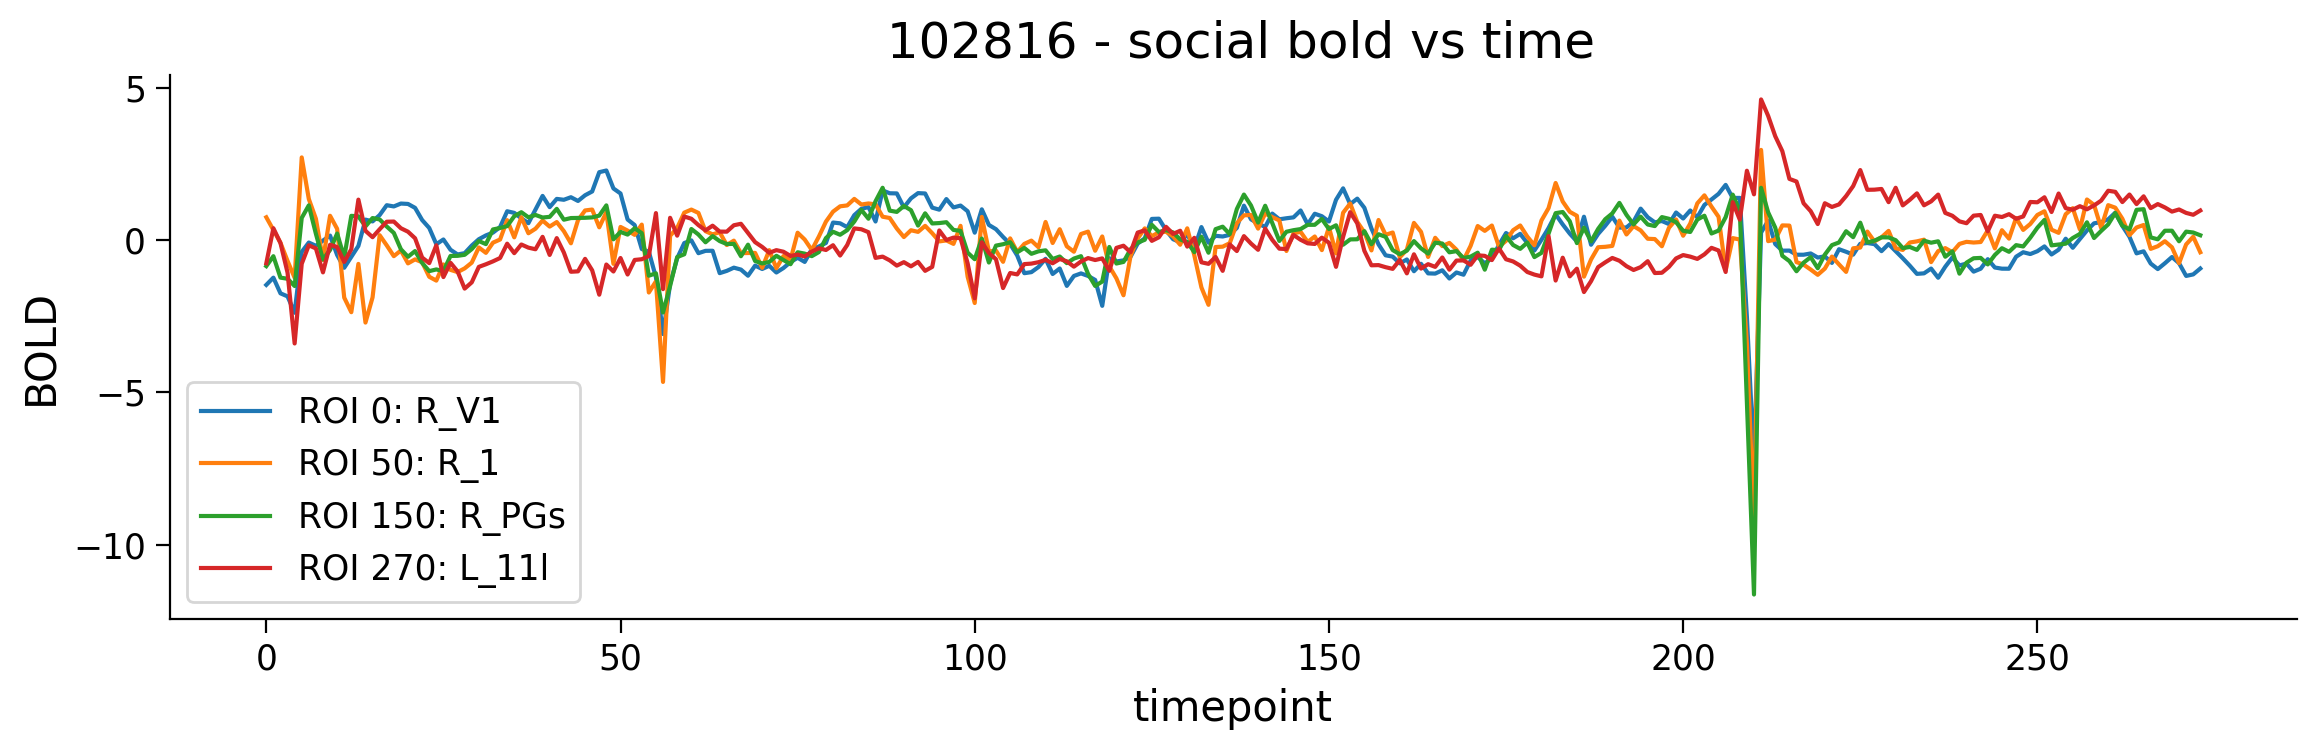

In [ ]:
import matplotlib.pyplot as plt

regions = np.load('hcp_task/regions.npy')

fig, ax = plt.subplots(figsize=(12, 4))
for roi_idx in [0, 50, 150, 270]:
    ax.plot(data_z[roi_idx, :], label=f'ROI {roi_idx}: {regions[roi_idx, 0]}')
ax.set_xlabel('timepoint')
ax.set_ylabel('BOLD')
ax.legend()
plt.title(' 102816 - social bold vs time')
plt.show()

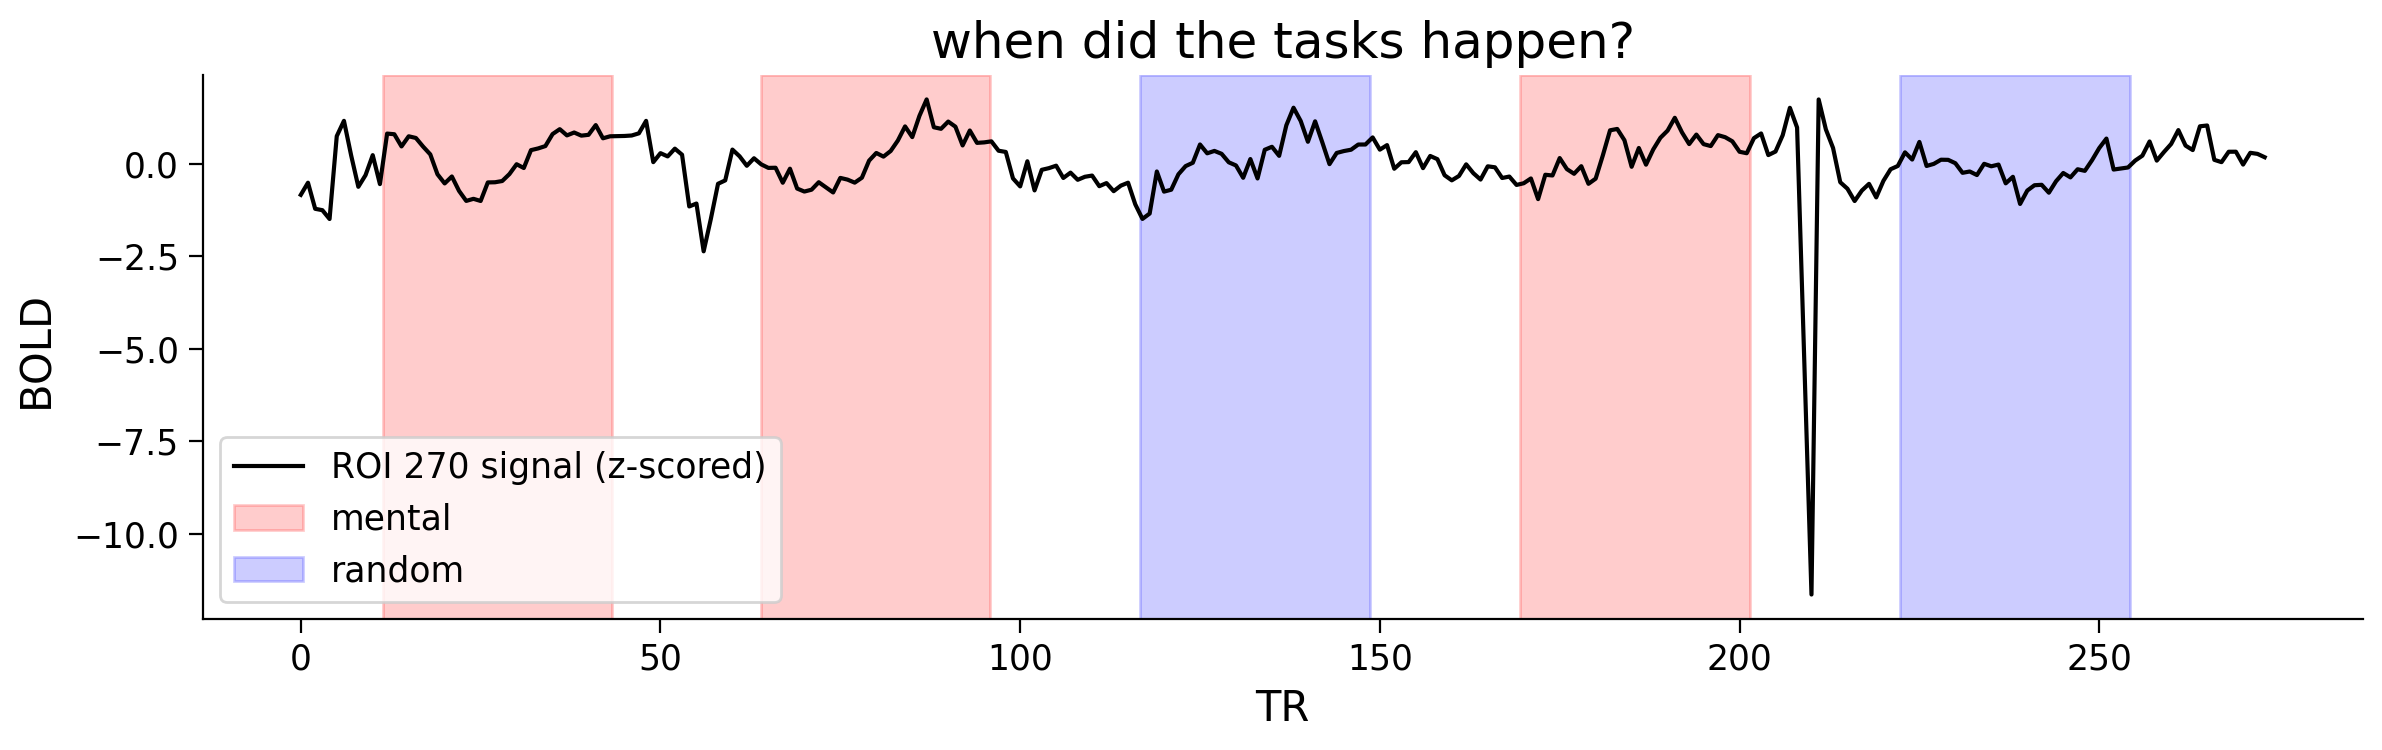

In [ ]:
mental = np.loadtxt('hcp_task/subjects/102816/SOCIAL/tfMRI_SOCIAL_LR/EVs/mental_resp.txt').reshape(-1, 3)
rnd = np.loadtxt('hcp_task/subjects/102816/SOCIAL/tfMRI_SOCIAL_LR/EVs/other_resp.txt').reshape(-1, 3)

TR = 0.72

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(data_z[150, :], color='black', label='ROI 270 signal (z-scored)')
for onset, dur, _ in mental:
    ax.axvspan(onset/TR, (onset+dur)/TR, color='red', alpha=0.2, label='mental' if onset==mental[0,0] else None)
for onset, dur, _ in rnd:
    ax.axvspan(onset/TR, (onset+dur)/TR, color='blue', alpha=0.2, label='random' if onset==rnd[0,0] else None)
ax.legend()
ax.set_xlabel('TR')
ax.set_ylabel('BOLD ')
plt.title('when did the tasks happen?')
plt.show()

# its time... to fly

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

TR = 0.72
n_TRs = 274

regions = np.load('hcp_task/regions.npy')

In [ ]:
def make_boxcar(ev_file, n_TRs, TR):
    """Turn an EV file (onset, duration, weight) into a 0/1 boxcar array of length n_TRs."""
    boxcar = np.zeros(n_TRs)
    events = np.loadtxt(ev_file).reshape(-1, 3)
    for onset, duration, weight in events:
        start_tr = int(onset / TR)
        end_tr = int((onset + duration) / TR)
        boxcar[start_tr:end_tr] = weight
    return boxcar

In [ ]:
!pip install nilearn

In [ ]:
from nilearn.glm.first_level import glover_hrf

hrf = glover_hrf(t_r=TR, oversampling=1, time_length=32)

def convolve_boxcar(boxcar, hrf):
    conv = np.convolve(boxcar, hrf)[:len(boxcar)]
    return conv

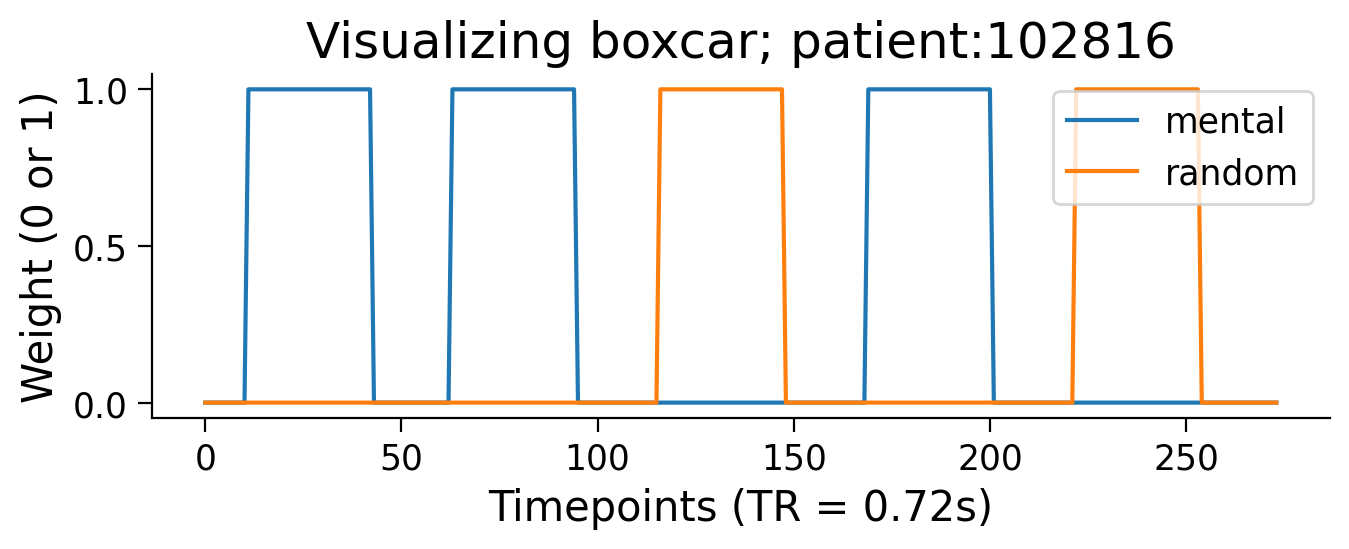

In [ ]:
mental_boxcar = make_boxcar('hcp_task/subjects/102816/SOCIAL/tfMRI_SOCIAL_LR/EVs/mental.txt', n_TRs, TR)
random_boxcar = make_boxcar('hcp_task/subjects/102816/SOCIAL/tfMRI_SOCIAL_LR/EVs/rnd.txt', n_TRs, TR)

mental_regressor = convolve_boxcar(mental_boxcar, hrf)

plt.figure(figsize=(7,3))
plt.plot(mental_boxcar, label='mental')
plt.plot(random_boxcar, label='random')
#plt.plot(mental_regressor, label='convolved (HRF-smeared) regressor')
plt.legend()
plt.xlabel('Timepoints (TR = 0.72s)')
plt.ylabel('Weight (0 or 1)')
plt.title('Visualizing boxcar; patient:102816')
plt.show()

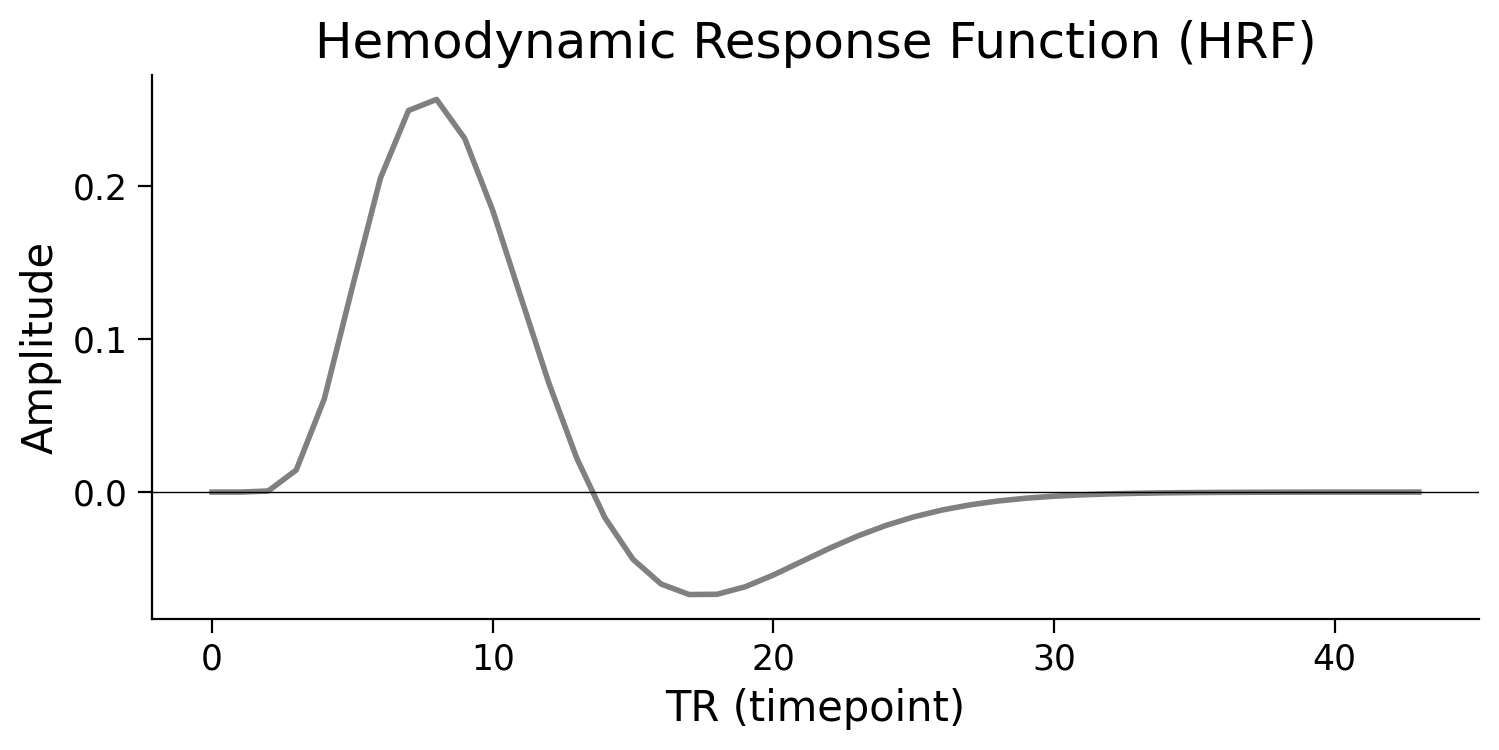

In [ ]:
import matplotlib.pyplot as plt
from nilearn.glm.first_level import glover_hrf

TR = 0.72
hrf = glover_hrf(t_r=TR, oversampling=1, time_length=32)

plt.figure(figsize=(8, 4))
plt.plot(hrf, color='gray', linewidth=2)
plt.title('Hemodynamic Response Function (HRF)')
plt.xlabel('TR (timepoint)')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

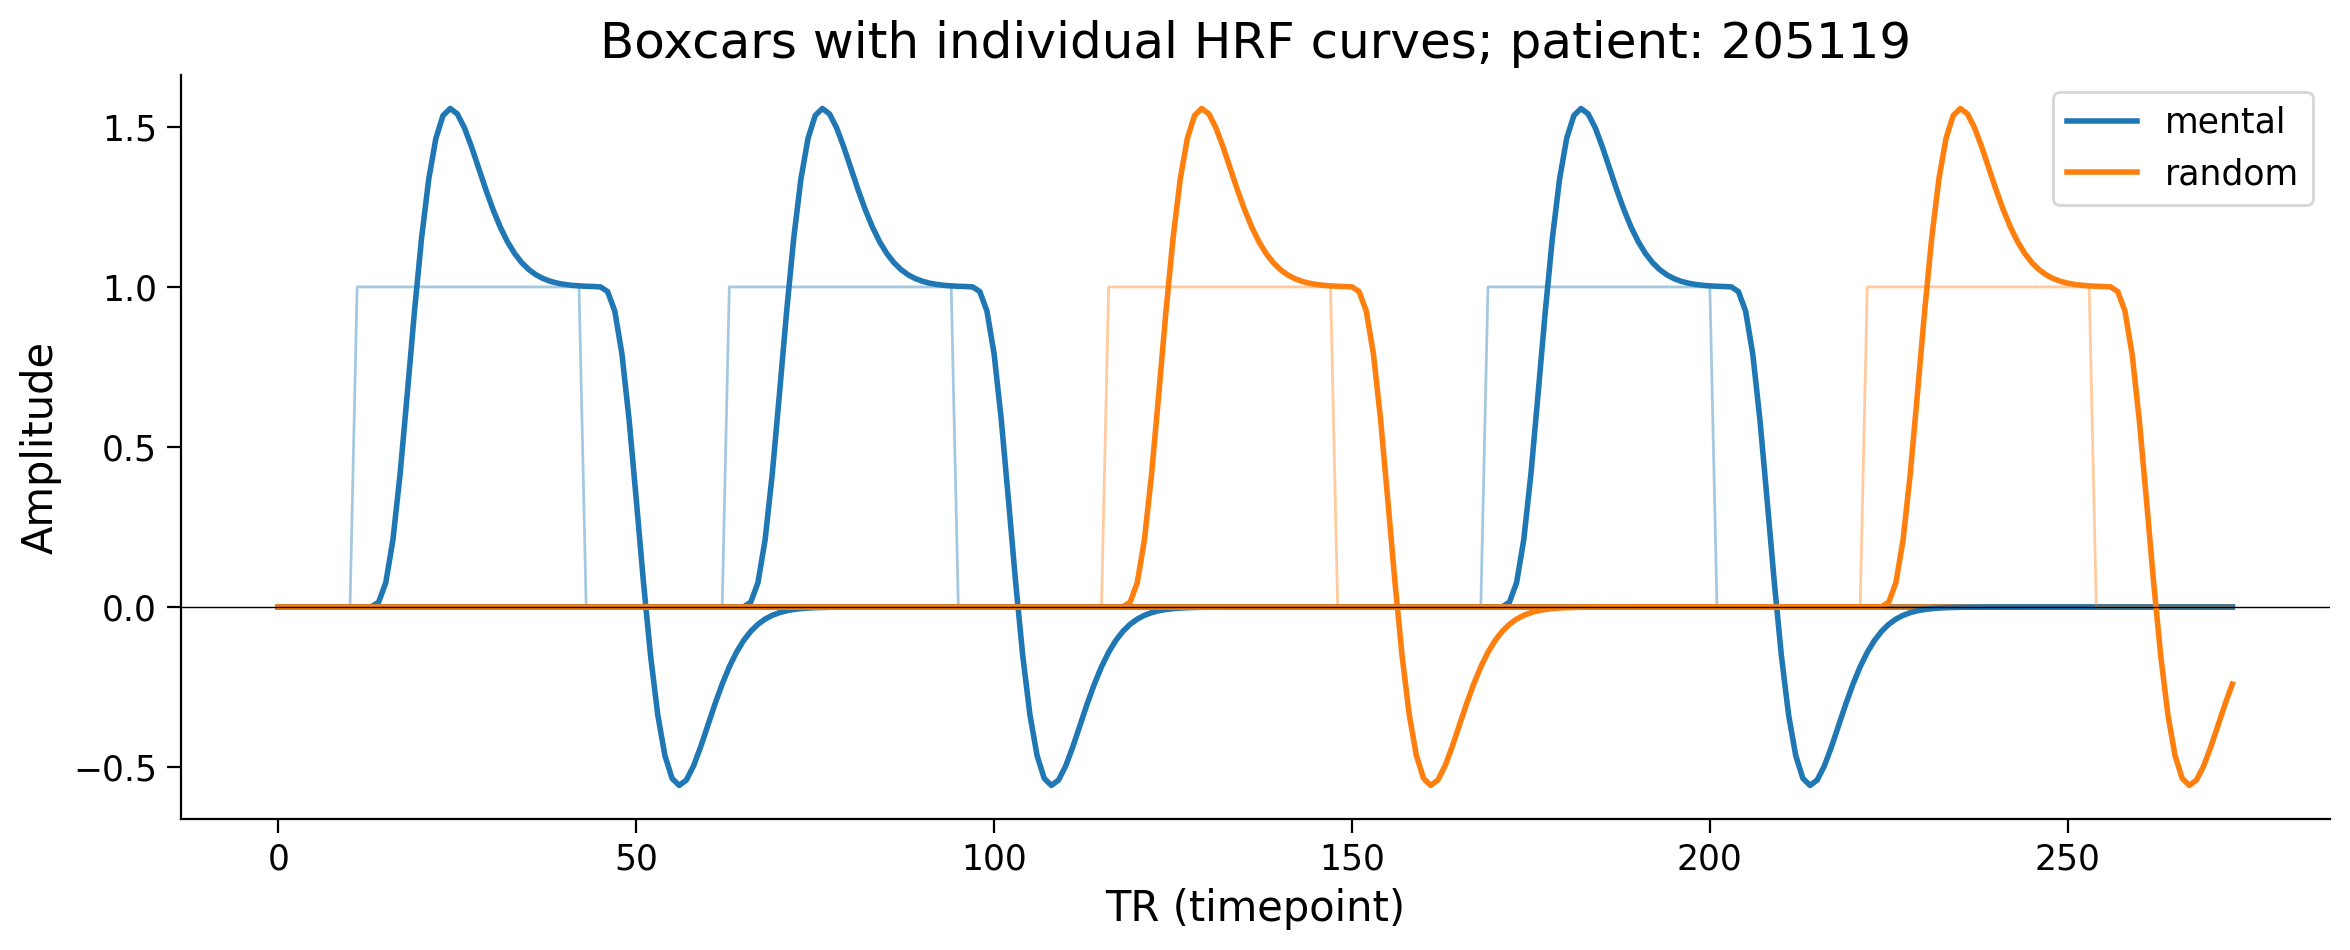

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# combine all 5 events with labels (same logic as your earlier trial-isolation step)
mental_events = np.loadtxt(f'{ev_path}/mental_resp.txt').reshape(-1, 3)
random_events = np.loadtxt(f'{ev_path}/other_resp.txt').reshape(-1, 3)

all_evs = np.vstack([mental_events, random_events])
labels = ['mental'] * len(mental_events) + ['random'] * len(random_events)

sort_idx = np.argsort(all_evs[:, 0])
all_evs = all_evs[sort_idx]
labels = [labels[i] for i in sort_idx]

# build one boxcar + one HRF curve per individual block
plt.figure(figsize=(12, 5))

colors = {'mental': 'tab:blue', 'random': 'tab:orange'}

for i, (onset, duration, weight) in enumerate(all_evs):
    single_boxcar = np.zeros(n_TRs)
    start_tr = int(onset / TR)
    end_tr = int((onset + duration) / TR)
    single_boxcar[start_tr:end_tr] = weight

    single_hrf_curve = convolve_boxcar(single_boxcar, hrf)

    # plot the raw boxcar (thin, flat rectangle)
    plt.plot(single_boxcar, color=colors[labels[i]], alpha=0.4, linewidth=1)
    # plot this block's own HRF-convolved curve
    plt.plot(single_hrf_curve, color=colors[labels[i]], linewidth=2,
              label=labels[i] if labels[i] not in plt.gca().get_legend_handles_labels()[1] else None)

plt.title(f'Boxcars with individual HRF curves; patient: {subj}')
plt.xlabel('TR (timepoint)')
plt.ylabel('Amplitude')
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

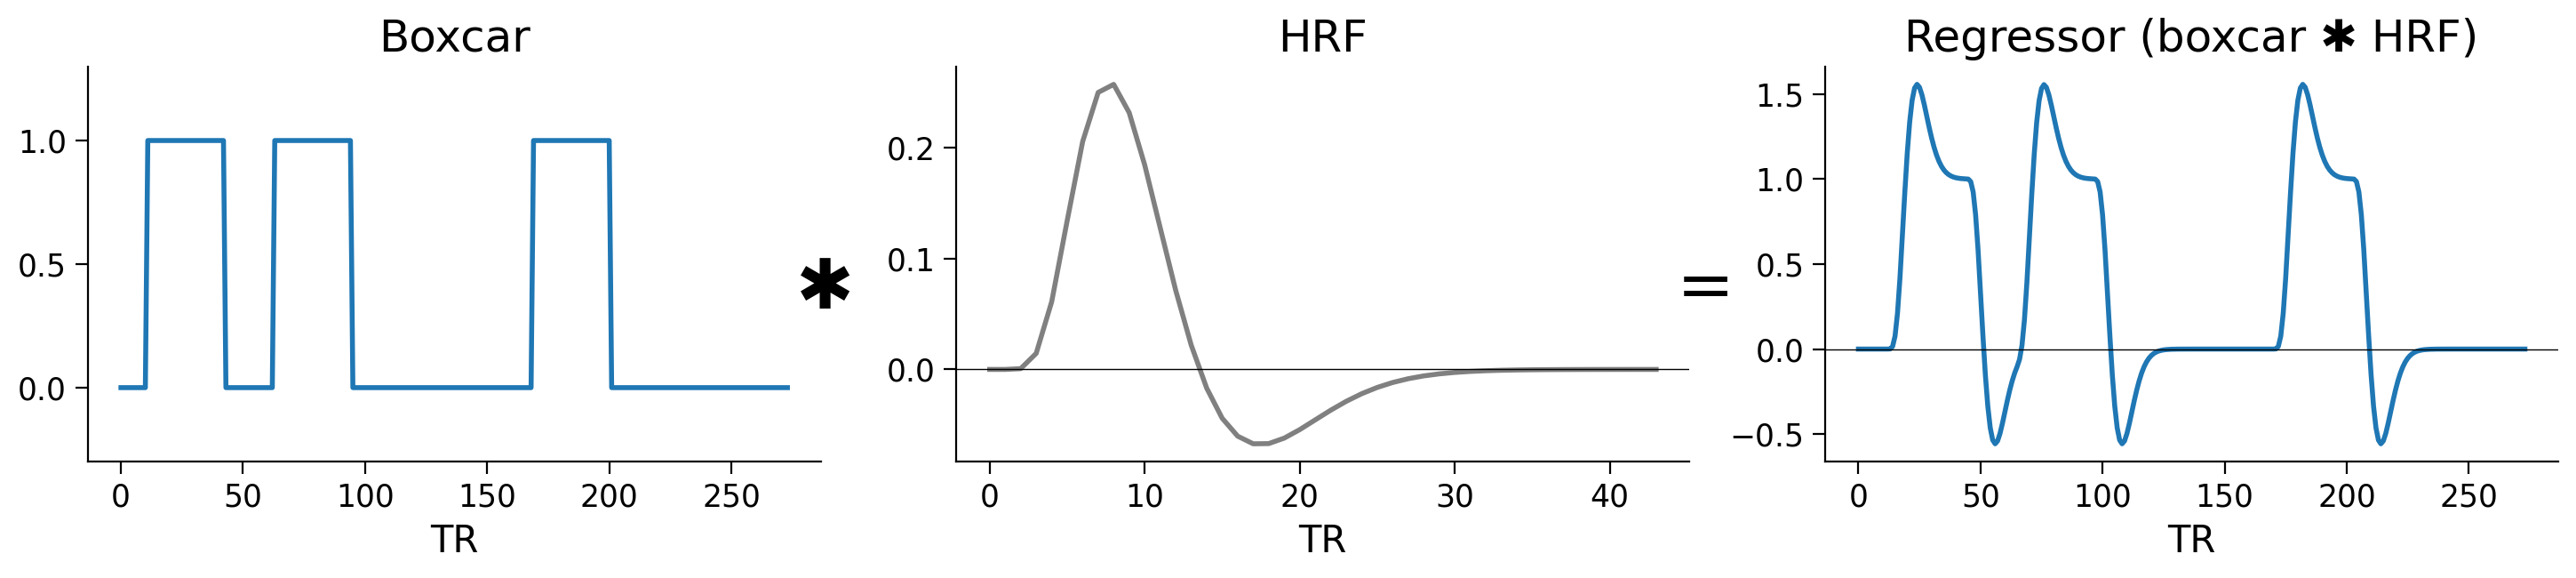

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

# Panel 1: boxcar
axes[0].plot(mental_boxcar, color='tab:blue', linewidth=2)
axes[0].set_title('Boxcar')
axes[0].set_xlabel('TR')
axes[0].set_ylim(-0.3, 1.3)

# Panel 2: HRF
axes[1].plot(hrf, color='gray', linewidth=2)
axes[1].set_title('HRF')
axes[1].set_xlabel('TR')
axes[1].axhline(0, color='black', linewidth=0.5)

# Panel 3: convolved regressor (the result)
axes[2].plot(mental_regressor, color='tab:blue', linewidth=2)
axes[2].set_title('Regressor (boxcar ✱ HRF)')
axes[2].set_xlabel('TR')
axes[2].axhline(0, color='black', linewidth=0.5)

# add convolution symbol and equals sign between panels
fig.text(0.335, 0.5, '✱', fontsize=28, ha='center', va='center')
fig.text(0.665, 0.5, '=', fontsize=28, ha='center', va='center')

plt.tight_layout()
plt.show()

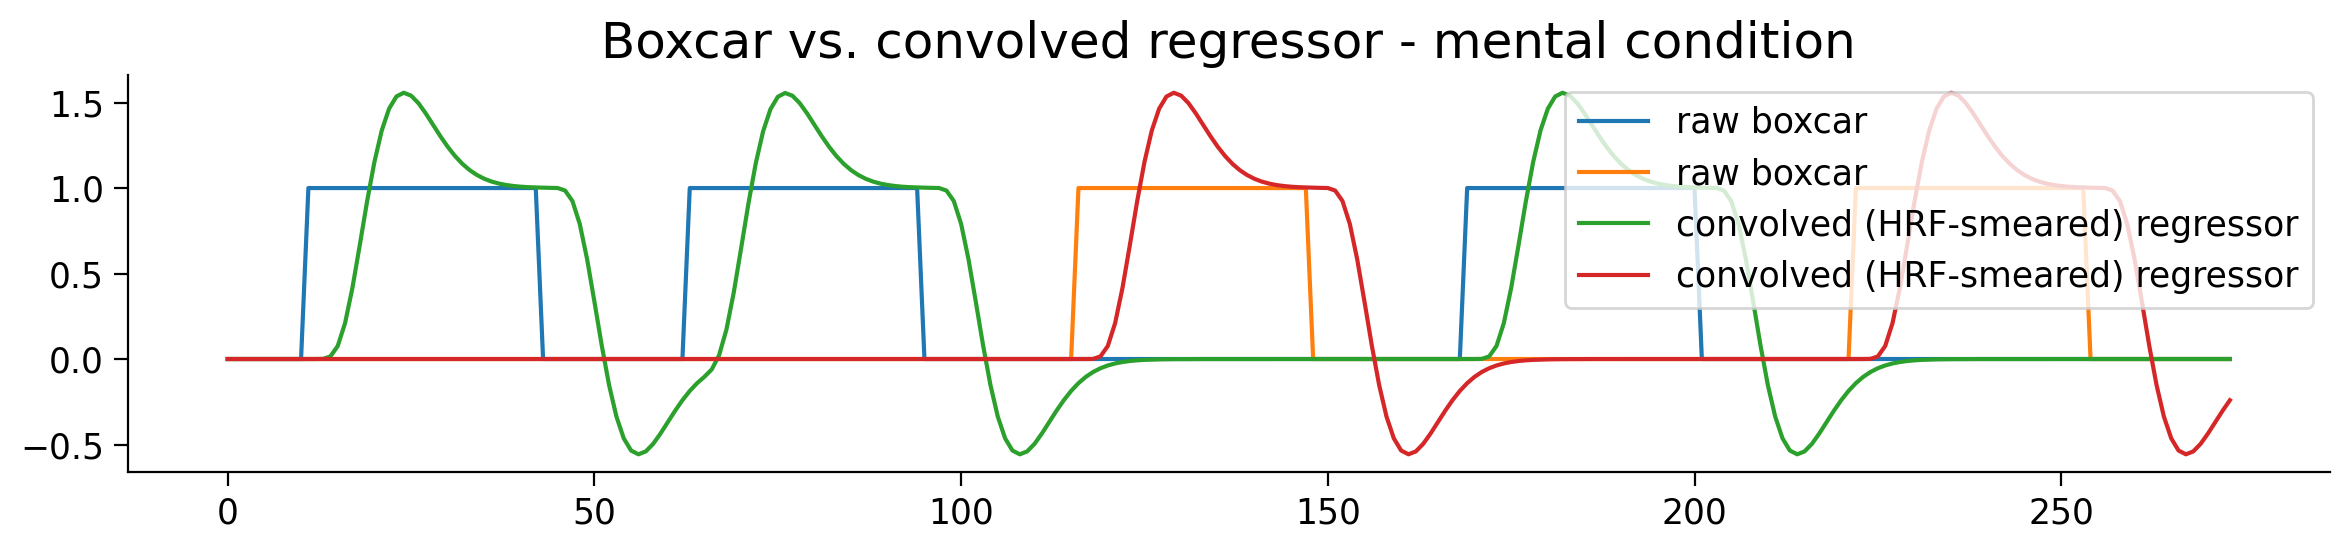

In [ ]:
subj = '102816'
run = 'tfMRI_SOCIAL_LR'
ev_path = f'hcp_task/subjects/{subj}/SOCIAL/{run}/EVs'

X_mental = convolve_boxcar(make_boxcar(f'{ev_path}/mental_resp.txt', n_TRs, TR), hrf)
X_random = convolve_boxcar(make_boxcar(f'{ev_path}/other_resp.txt', n_TRs, TR), hrf)

plt.figure(figsize=(12,3))
plt.plot(mental_boxcar, label='raw boxcar')
plt.plot(random_boxcar, label='raw boxcar')
plt.plot(X_mental, label='convolved (HRF-smeared) regressor')
plt.plot(X_random, label='convolved (HRF-smeared) regressor')
plt.legend()
plt.title('Boxcar vs. convolved regressor - mental condition')
plt.show()

In [ ]:
data = np.load(f'hcp_task/subjects/{subj}/SOCIAL/{run}/data.npy')  # (360, 274)
data_z = (data - data.mean(axis=1, keepdims=True)) / data.std(axis=1, keepdims=True)


In [ ]:
intercept = np.ones(n_TRs)
drift = np.linspace(-1, 1, n_TRs) # claude

design_matrix = np.column_stack([X_mental, X_random, intercept, drift])
design_matrix

array([[ 0.        ,  0.        ,  1.        , -1.        ],
       [ 0.        ,  0.        ,  1.        , -0.99267399],
       [ 0.        ,  0.        ,  1.        , -0.98534799],
       ...,
       [ 0.        , -0.3695854 ,  1.        ,  0.98534799],
       [ 0.        , -0.30281161,  1.        ,  0.99267399],
       [ 0.        , -0.24095416,  1.        ,  1.        ]])

In [ ]:
design_matrix[:, 0]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        5.00343625e-12,  7.10449309e-04,  1.51389229e-02,  7.60618761e-02,
        2.09988969e-01,  4.15197176e-01,  6.64559038e-01,  9.21182199e-01,
        1.15236508e+00,  1.33651165e+00,  1.46408167e+00,  1.53538078e+00,
        1.55735820e+00,  1.54054866e+00,  1.49660375e+00,  1.43652670e+00,
        1.36958540e+00,  1.30281161e+00,  1.24095416e+00,  1.18673657e+00,
        1.14127569e+00,  1.10454480e+00,  1.07580030e+00,  1.05392849e+00,
        1.03769777e+00,  1.02592224e+00,  1.01755273e+00,  1.01171493e+00,
        1.00771294e+00,  1.00501305e+00,  1.00321850e+00,  1.00204211e+00,
        1.00128086e+00,  1.00008374e+00,  9.85347660e-01,  9.24232349e-01,
        7.90186177e-01,  5.84904953e-01,  3.35498722e-01,  7.88488287e-02,
       -1.52350031e-01, -

In [ ]:
betas = np.zeros((360, design_matrix.shape[1]))
for roi in range(360):
  y = data_z[roi, :]
  beta, residuals, rank, sv = np.linalg.lstsq(design_matrix, y, rcond=None)
  betas[roi] = beta


In [ ]:
betas

array([[ 0.78867089,  0.3634792 , -0.36212019, -0.1362622 ],
       [ 0.87854559,  0.87633865, -0.51466718,  0.41426165],
       [-0.23018503, -0.19161348,  0.12587822,  0.09707143],
       ...,
       [ 0.09071155,  0.31588342, -0.10634493,  0.46410275],
       [ 0.08013297, -0.00850653, -0.02606786, -0.59653154],
       [ 0.21414912,  0.2097318 , -0.12453655, -0.7446398 ]])

In [ ]:
contrast_mental_vs_random = betas[:, 0] - betas[:, 1]

In [ ]:
contrast_mental_vs_random


array([ 0.42519169,  0.00220694, -0.03857156,  0.20372125,  0.4699417 ,
        0.39446438,  0.57908669,  0.00394854,  0.36620872,  0.34407016,
        0.28378474,  0.37981305, -0.0038179 ,  0.35070213,  0.23401092,
        0.06235398, -0.01792184,  0.39085385,  0.15293139,  0.5052137 ,
        0.42660254,  0.41199939,  0.2186679 ,  0.0188079 ,  0.09946066,
        0.09611716,  0.14978513, -0.0342882 ,  0.02472604,  0.4419144 ,
        0.40201102, -0.16344103,  0.1885103 ,  0.12043305,  0.20581101,
        0.0895726 ,  0.05782715, -0.35229574,  0.23987312, -0.1061226 ,
       -0.06680327,  0.03744741,  0.14888623, -0.29719225, -0.07587548,
        0.15974198, -0.27145343,  0.09440687,  0.07653255,  0.2260498 ,
        0.12735458,  0.04590421,  0.13245543,  0.26747944, -0.38801148,
       -0.08801852, -0.0658053 ,  0.03613237,  0.03593642,  0.12401583,
        0.19870771,  0.18735566,  0.19168799,  0.15197858, -0.03943994,
        0.28169848,  0.40694361,  0.29026961,  0.3562652 ,  0.18

In [ ]:
order = np.argsort(contrast_mental_vs_random)[::-1]

In [ ]:
print("Top 10 ROIs (mental > random) for subject 102816:")
for i in order[:10]:
    print(f"{regions[i, 0]}: {contrast_mental_vs_random[i]:.3f}")

Top 10 ROIs (mental > random) for subject 102816:
L_PGs: 0.673
L_PGp: 0.625
R_IFSp: 0.611
R_31pd: 0.608
L_31pd: 0.604
R_IFJp: 0.596
R_PHT: 0.589
L_PHT: 0.581
L_8Av: 0.580
R_V8: 0.579


Randomly selected ROI: 304 (L_A5)


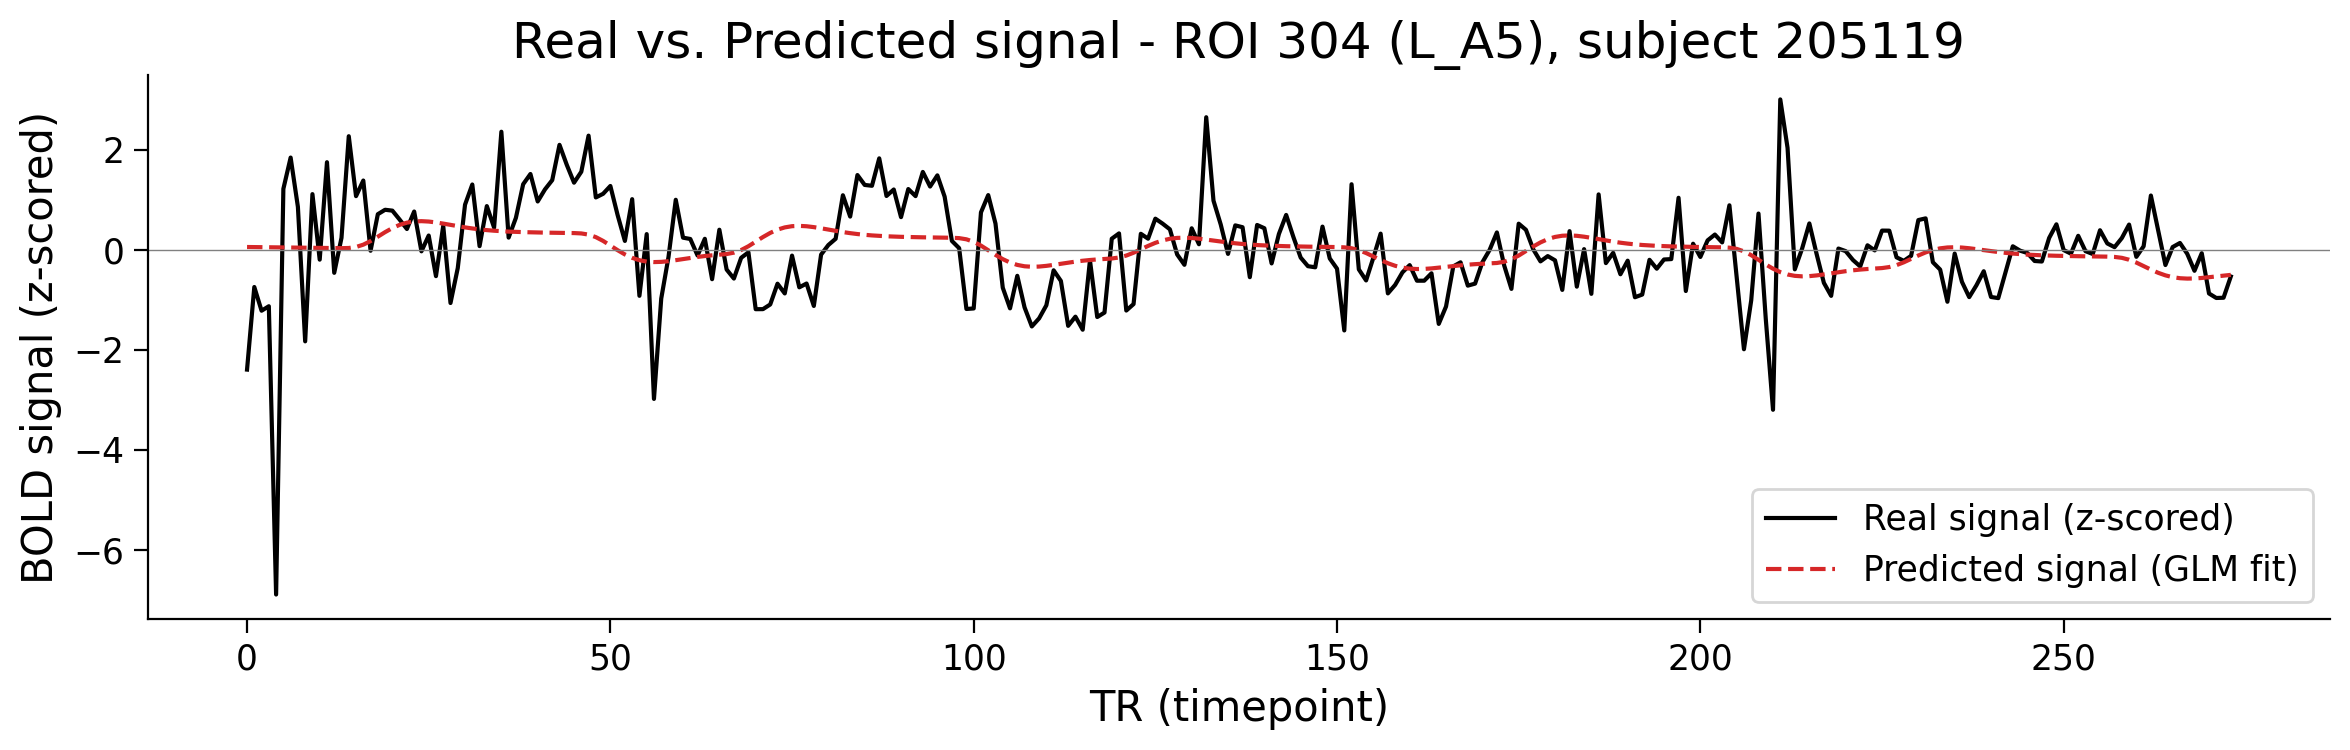


Fitted betas: mental=0.360, random=0.269, intercept=-0.190, drift=-0.246


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed()  # no fixed seed - genuinely random each run
random_roi = np.random.randint(0, 360)
print(f"Randomly selected ROI: {random_roi} ({regions[random_roi, 0]})")

# real signal for this ROI
y_real = data_z[random_roi, :]

# refit just this ROI to get its betas explicitly (or reuse from your betas matrix if already computed)
beta, _, _, _ = np.linalg.lstsq(design_matrix, y_real, rcond=None)

# predicted signal = design_matrix @ beta
y_predicted = design_matrix @ beta

# plot real vs predicted
plt.figure(figsize=(12, 4))
plt.plot(y_real, color='black', label='Real signal (z-scored)', linewidth=1.5)
plt.plot(y_predicted, color='tab:red', label='Predicted signal (GLM fit)', linewidth=1.5, linestyle='--')
plt.title(f'Real vs. Predicted signal - ROI {random_roi} ({regions[random_roi,0]}), subject {subj}')
plt.xlabel('TR (timepoint)')
plt.ylabel('BOLD signal (z-scored)')
plt.legend()
plt.axhline(0, color='gray', linewidth=0.5)
plt.show()

print(f"\nFitted betas: mental={beta[0]:.3f}, random={beta[1]:.3f}, intercept={beta[2]:.3f}, drift={beta[3]:.3f}")

### all subs_glm

In [ ]:
with open('hcp_task/subjects_list.txt') as f:
    subject_ids = f.read().split()

print(len(subject_ids), subject_ids[:5])

100 ['100307', '100408', '101915', '102816', '103414']


In [ ]:
def get_subject_contrast(subj, run, n_TRs, TR, hrf):
    ev_path = f'hcp_task/subjects/{subj}/SOCIAL/{run}/EVs'

    X_mental = convolve_boxcar(make_boxcar(f'{ev_path}/mental_resp.txt', n_TRs, TR), hrf)
    X_random = convolve_boxcar(make_boxcar(f'{ev_path}/other_resp.txt', n_TRs, TR), hrf)

    data = np.load(f'hcp_task/subjects/{subj}/SOCIAL/{run}/data.npy')
    data_z = (data - data.mean(axis=1, keepdims=True)) / data.std(axis=1, keepdims=True)

    intercept = np.ones(n_TRs)
    drift = np.linspace(-1, 1, n_TRs)
    design_matrix = np.column_stack([X_mental, X_random, intercept, drift])

    betas = np.zeros((360, design_matrix.shape[1]))
    for roi in range(360):
        y = data_z[roi, :]
        beta, _, _, _ = np.linalg.lstsq(design_matrix, y, rcond=None)
        betas[roi] = beta

    return betas[:, 0] - betas[:, 1]

In [ ]:
subject_contrasts = []
failed = []

for subj in subject_ids:
    run_contrasts = []
    for run in ['tfMRI_SOCIAL_LR', 'tfMRI_SOCIAL_RL']:
        try:
            c = get_subject_contrast(subj, run, n_TRs, TR, hrf)
            run_contrasts.append(c)
        except Exception as e:
            failed.append((subj, run, str(e)))
    if len(run_contrasts) > 0:
        subject_contrasts.append(np.mean(run_contrasts, axis=0))

subject_contrasts = np.array(subject_contrasts)
print(f"Valid subjects: {subject_contrasts.shape[0]} / {len(subject_ids)}")
print(f"Failed runs: {len(failed)}")

/tmp/ipykernel_2075/3637529044.py:4: UserWarning: loadtxt: input contained no data: "hcp_task/subjects/125525/SOCIAL/tfMRI_SOCIAL_RL/EVs/mental_resp.txt"
  events = np.loadtxt(ev_file).reshape(-1, 3)
/tmp/ipykernel_2075/3637529044.py:4: UserWarning: loadtxt: input contained no data: "hcp_task/subjects/133827/SOCIAL/tfMRI_SOCIAL_RL/EVs/mental_resp.txt"
  events = np.loadtxt(ev_file).reshape(-1, 3)
/tmp/ipykernel_2075/3637529044.py:4: UserWarning: loadtxt: input contained no data: "hcp_task/subjects/192439/SOCIAL/tfMRI_SOCIAL_RL/EVs/mental_resp.txt"
  events = np.loadtxt(ev_file).reshape(-1, 3)


Valid subjects: 100 / 100
Failed runs: 0


In [ ]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

t_vals, p_vals = stats.ttest_1samp(subject_contrasts, popmean=0, axis=0)
reject, p_fdr, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')
significant_rois = np.where(reject)[0]

print(f"{len(significant_rois)} ROIs significant after FDR correction\n")

order = significant_rois[np.argsort(t_vals[significant_rois])[::-1]]
for i in order:
    print(f"{regions[i,0]} ({regions[i,1]}): t={t_vals[i]:.2f}, mean_contrast={subject_contrasts[:,i].mean():.3f}, p_fdr={p_fdr[i]:.4f}")

246 ROIs significant after FDR correction

L_PH (Visual2): t=17.08, mean_contrast=0.350, p_fdr=0.0000
L_FFC (Visual2): t=16.67, mean_contrast=0.341, p_fdr=0.0000
L_PHT (Language): t=16.10, mean_contrast=0.372, p_fdr=0.0000
L_TE2p (Language): t=15.99, mean_contrast=0.349, p_fdr=0.0000
R_PH (Visual2): t=15.81, mean_contrast=0.339, p_fdr=0.0000
R_PHA3 (Language): t=15.37, mean_contrast=0.292, p_fdr=0.0000
R_VVC (Visual2): t=15.09, mean_contrast=0.287, p_fdr=0.0000
R_TPOJ1 (Default): t=15.03, mean_contrast=0.380, p_fdr=0.0000
R_TE2p (Language): t=14.29, mean_contrast=0.323, p_fdr=0.0000
L_VVC (Visual2): t=13.86, mean_contrast=0.290, p_fdr=0.0000
R_TPOJ2 (Dorsal-atten): t=13.82, mean_contrast=0.316, p_fdr=0.0000
R_FFC (Visual2): t=13.26, mean_contrast=0.310, p_fdr=0.0000
R_STSdp (Default): t=13.13, mean_contrast=0.390, p_fdr=0.0000
R_PHA2 (Posterior-Mu): t=12.88, mean_contrast=0.248, p_fdr=0.0000
L_STV (Dorsal-atten): t=12.32, mean_contrast=0.297, p_fdr=0.0000
R_FST (Visual2): t=12.25, mean

In [ ]:
print(f"Total ROIs tested: 360")
print(f"Significant after FDR correction: {len(significant_rois)} ({len(significant_rois)/360*100:.0f}%)")
print(f"Mental > Random: {(t_vals[significant_rois] > 0).sum()}")
print(f"Random > Mental: {(t_vals[significant_rois] < 0).sum()}")

Total ROIs tested: 360
Significant after FDR correction: 246 (68%)
Mental > Random: 131
Random > Mental: 115


In [ ]:
top15_idx = significant_rois[np.argsort(t_vals[significant_rois])[::-1]][:15]

for i in top15_idx:
    print(f"{regions[i,0]:10s} ({regions[i,1]:15s}): t={t_vals[i]:.2f}, contrast={subject_contrasts[:,i].mean():.3f}")

L_PH       (Visual2        ): t=17.08, contrast=0.350
L_FFC      (Visual2        ): t=16.67, contrast=0.341
L_PHT      (Language       ): t=16.10, contrast=0.372
L_TE2p     (Language       ): t=15.99, contrast=0.349
R_PH       (Visual2        ): t=15.81, contrast=0.339
R_PHA3     (Language       ): t=15.37, contrast=0.292
R_VVC      (Visual2        ): t=15.09, contrast=0.287
R_TPOJ1    (Default        ): t=15.03, contrast=0.380
R_TE2p     (Language       ): t=14.29, contrast=0.323
L_VVC      (Visual2        ): t=13.86, contrast=0.290
R_TPOJ2    (Dorsal-atten   ): t=13.82, contrast=0.316
R_FFC      (Visual2        ): t=13.26, contrast=0.310
R_STSdp    (Default        ): t=13.13, contrast=0.390
R_PHA2     (Posterior-Mu   ): t=12.88, contrast=0.248
L_STV      (Dorsal-atten   ): t=12.32, contrast=0.297


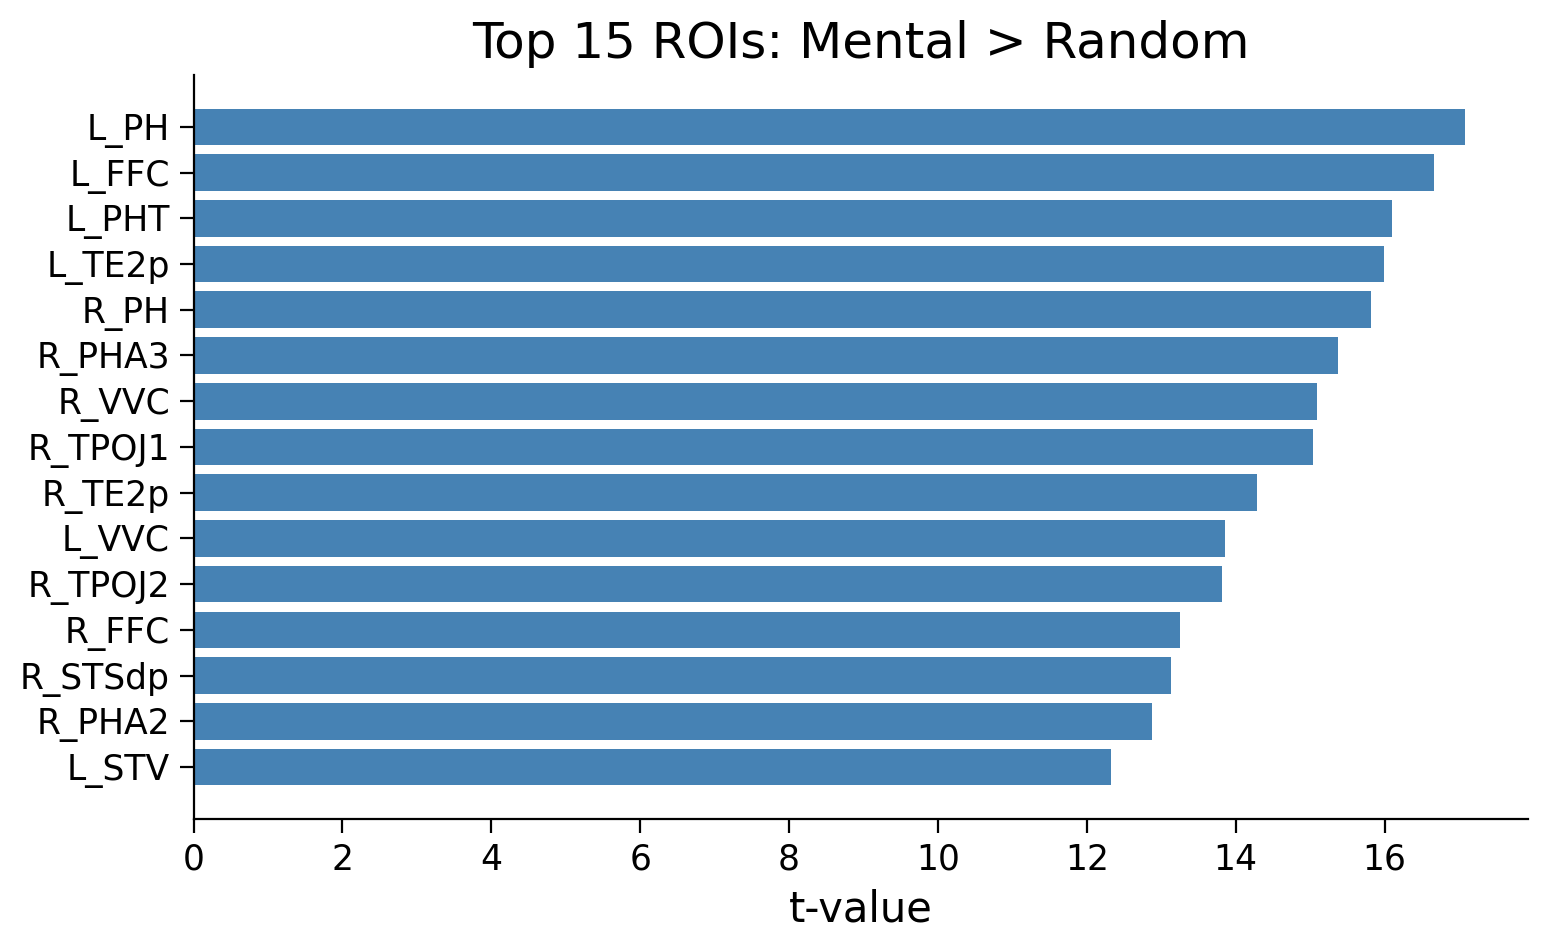

In [ ]:
import matplotlib.pyplot as plt

top15_idx = significant_rois[np.argsort(t_vals[significant_rois])[::-1]][:15]
names = [regions[i,0] for i in top15_idx]
t_top = t_vals[top15_idx]

plt.figure(figsize=(8,5))
plt.barh(names[::-1], t_top[::-1], color='steelblue')
plt.xlabel('t-value')
plt.title('Top 15 ROIs: Mental > Random')
plt.tight_layout()
plt.savefig('top15_rois.png', dpi=150)
plt.show()

# exploring MVPA... again... blast off!

what we have been doing was just basically lumping all mental and random blocks/events into one array... 1 sample. for MVPA or any type of classifier(ml), we gonna need more than that.

more samples... better prediction... basically!

the idea (though vaguely) is this: from 1 sample where we have info about 5 events (3 mental, 2 random), we seperate that into 5 different samples.

essentially, we have 100 subjects, each performing 2 runs, and 5 blocks.. so 100 x 2 x 5 = nearly 1000 samples (good enough for a classifier)

lets do this for ONE SUBJECT... SAME GUY/GAL

In [ ]:
mental_events = np.loadtxt(f'{ev_path}/mental_resp.txt').reshape(-1, 3)
random_events = np.loadtxt(f'{ev_path}/other_resp.txt').reshape(-1, 3)

In [ ]:
mental_events

array([[  8.183,  23.   ,   1.   ],
       [ 46.013,  23.   ,   1.   ],
       [122.073,  23.   ,   1.   ]])

In [ ]:
random_events

array([[ 84.043,  23.   ,   1.   ],
       [160.102,  23.   ,   1.   ]])

In [ ]:
all_evs = np.vstack([mental_events, random_events])

In [ ]:
all_evs[:, 0]

array([  8.183,  46.013, 122.073,  84.043, 160.102])

In [ ]:
labels = ['M'] * len(mental_events) + ['R'] * len(random_events)

In [ ]:
labels

['M', 'M', 'M', 'R', 'R']

In [ ]:
sort_idx = np.argsort(all_evs[:, 0]) # all_evs[:, 0] => take evertyhin from first column (onset)
print(sort_idx)
all_evs = all_evs[sort_idx]

[0 1 3 2 4]


##### [0 1 3 2 4] is because in the all_evs, 0th index is M, 1st index is M, 3rd index is random, 2nd index is M, 4th index is Random... arranging based on the onset values... which ones came first...

In [ ]:
all_evs

array([[  8.183,  23.   ,   1.   ],
       [ 46.013,  23.   ,   1.   ],
       [ 84.043,  23.   ,   1.   ],
       [122.073,  23.   ,   1.   ],
       [160.102,  23.   ,   1.   ]])

In [ ]:
labels

['M', 'M', 'M', 'R', 'R']

In [ ]:
labels = [labels[i] for i in sort_idx]


In [ ]:
labels

['M', 'M', 'R', 'M', 'R']

## we now isolate one box at a time...

In [ ]:
def isolate_boxcars(all_evs, pos_boxcar, n_TRs, TR):
  current_boxcar = np.zeros(n_TRs)
  other_boxcars = np.zeros(n_TRs)

  for i, (onset, duration, weight) in enumerate(all_evs):
    start_tr = int(onset/TR)
    end_tr = int((onset + duration)/TR)
    if i == pos_boxcar:
      current_boxcar[start_tr:end_tr] = weight
    else:
      other_boxcars[start_tr:end_tr] = weight

  return current_boxcar, other_boxcars

In [ ]:
cur_boxcar, other_boxcars = isolate_boxcars(all_evs, 0, n_TRs, TR)

In [ ]:
cur_boxcar, other_boxcars

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 

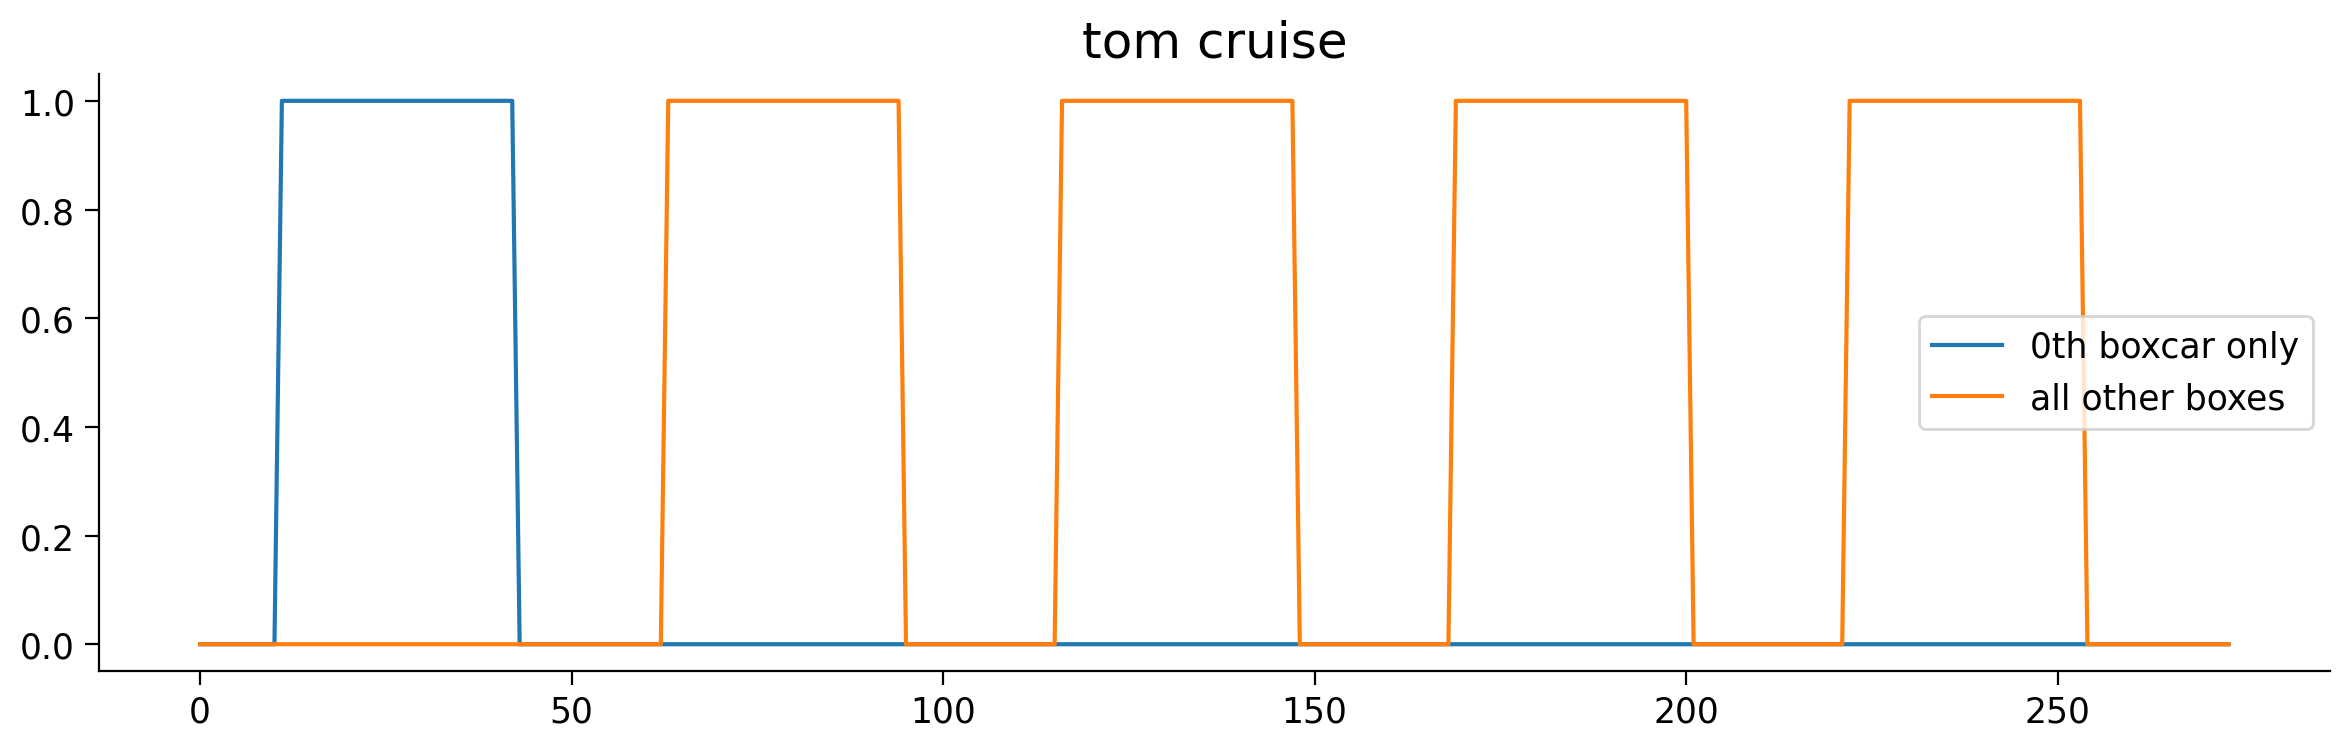

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(cur_boxcar, label='0th boxcar only')
plt.plot(other_boxcars, label='all other boxes')
plt.legend()
plt.title("tom cruise")
plt.show()

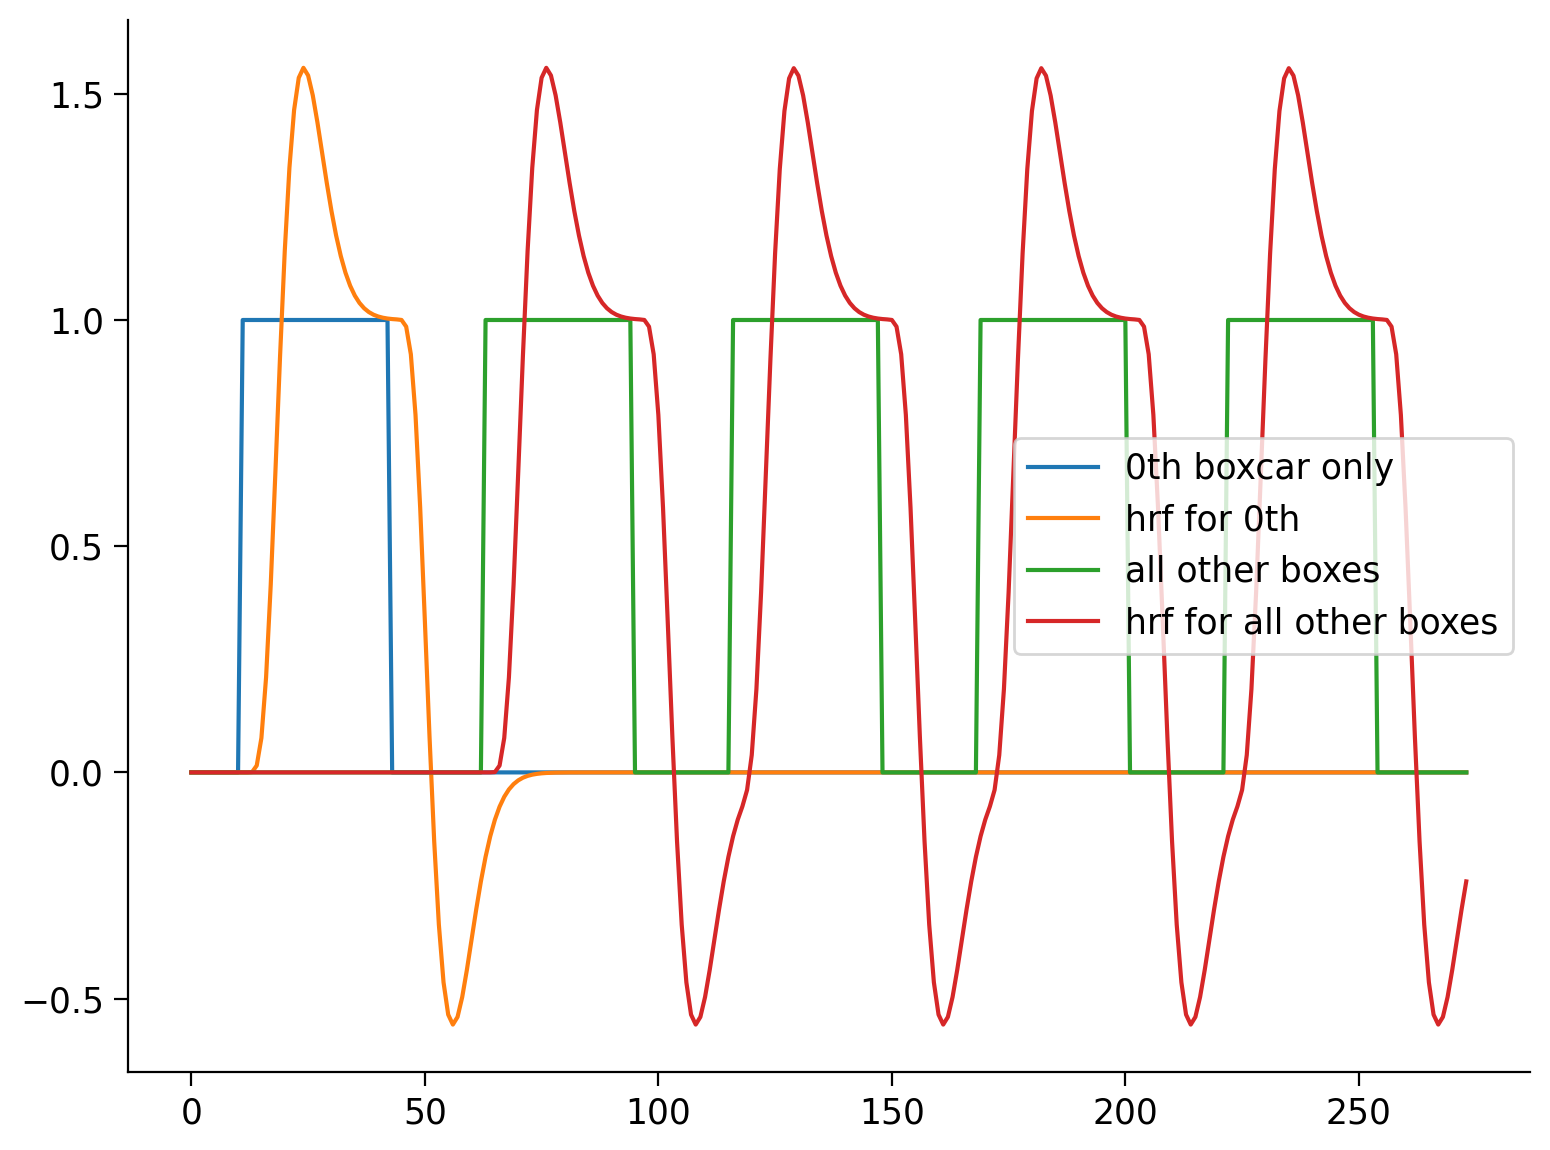

In [ ]:
X_this = convolve_boxcar(cur_boxcar, hrf)
X_other = convolve_boxcar(other_boxcars, hrf)

plt.plot(cur_boxcar, label='0th boxcar only')
plt.plot(X_this, label='hrf for 0th')
plt.plot(other_boxcars, label='all other boxes')
plt.plot(X_other, label='hrf for all other boxes')
plt.legend()
plt.show()

In [ ]:
design_matrix_single = np.column_stack([X_this, X_other, intercept, drift])

betas_this_trial = np.zeros(360)
for roi in range(360):
    y = data_z[roi, :]
    beta, _, _, _ = np.linalg.lstsq(design_matrix_single, y, rcond=None)
    betas_this_trial[roi] = beta[0]  # only interested in beta for the 0th block

print(betas_this_trial.shape)
print(labels[0])

(360,)
M


whats betas_this_trial? =======>>>>>>>> HOW STRONGLY A ROI's SINGLE MATCHED WITH BLOCK 0'S TIMING PATTERN (Orange curve above)

### So far, we only accounted for 0th block... we need to do the same thing for the remaining blocks for every subject for every run... lets put it all in a function...

In [ ]:
def get_single_trial_betas(all_evs, labels, data_z, n_TRs, TR, hrf, intercept, drift):
    n_trials = len(all_evs)
    trial_betas = np.zeros((n_trials, 360))

    for pos_boxcar in range(n_trials):
        cur_boxcar, other_boxcars = isolate_boxcars(all_evs, pos_boxcar, n_TRs, TR)
        X_this = convolve_boxcar(cur_boxcar, hrf)
        X_other = convolve_boxcar(other_boxcars, hrf)

        design_matrix_single = np.column_stack([X_this, X_other, intercept, drift])

        for roi in range(360):
            y = data_z[roi, :]
            beta, _, _, _ = np.linalg.lstsq(design_matrix_single, y, rcond=None)
            trial_betas[pos_boxcar, roi] = beta[0]

    return trial_betas, labels

In [ ]:
trial_betas, trial_labels = get_single_trial_betas(all_evs, labels, data_z, n_TRs, TR, hrf, intercept, drift)
print(trial_betas.shape)
print(trial_labels)

(5, 360)
['M', 'M', 'R', 'M', 'R']


In [ ]:
trial_betas

array([[ 0.86425395,  0.51466208, -0.06482643, ...,  0.68405929,
         0.13963247,  0.47327147],
       [ 0.64279942,  0.90023085, -0.20165339, ...,  0.24742579,
        -0.00848302,  0.2207028 ],
       [ 0.75811394,  1.12069043,  0.24611311, ...,  0.22429598,
        -0.11746188,  0.07723118],
       [ 0.84606134,  1.16324754, -0.39547352, ..., -0.55137941,
         0.11285392, -0.01067267],
       [-0.10995951,  0.57332962, -0.73602398, ...,  0.42098093,
         0.12998978,  0.37425162]])

## now, we accounted for 5 blocks... thats just one subject... lets do it for all subs, all runs

another FFFFUUUUUUNNNNNNNCCCCCCCCTTTTTTTTTTIIIIIIIIIIOOOOOOOOOOONNNNNNNN!!!!!

In [ ]:
def process_subject_run(subj, run, n_TRs, TR, hrf):
    ev_path = f'hcp_task/subjects/{subj}/SOCIAL/{run}/EVs'

    mental_events = np.loadtxt(f'{ev_path}/mental.txt').reshape(-1, 3)
    random_events = np.loadtxt(f'{ev_path}/rnd.txt').reshape(-1, 3)

    all_evs = np.vstack([mental_events, random_events])
    labels = ['M'] * len(mental_events) + ['R'] * len(random_events)

    sort_idx = np.argsort(all_evs[:, 0])
    all_evs = all_evs[sort_idx]
    labels = [labels[i] for i in sort_idx]

    data = np.load(f'hcp_task/subjects/{subj}/SOCIAL/{run}/data.npy')
    data_z = (data - data.mean(axis=1, keepdims=True)) / data.std(axis=1, keepdims=True)

    intercept = np.ones(n_TRs)
    drift = np.linspace(-1, 1, n_TRs)

    trial_betas, trial_labels = get_single_trial_betas(all_evs, labels, data_z, n_TRs, TR, hrf, intercept, drift)
    return trial_betas, trial_labels

In [ ]:
X_all = []
y_all = []
subject_group = []
failed = []

with open("/content/hcp_task/subjects_list.txt", 'r') as f:
  subject_ids = f.read().split()

print(subject_ids)

['100307', '100408', '101915', '102816', '103414', '103515', '103818', '105115', '105216', '106016', '106319', '110411', '111009', '111312', '111514', '111716', '113215', '113619', '114924', '115320', '117122', '117324', '118730', '118932', '119833', '120111', '120212', '122317', '123117', '124422', '125525', '126325', '127933', '128632', '129028', '130013', '130316', '130922', '131924', '133625', '133827', '133928', '134324', '135932', '136833', '137128', '138231', '138534', '139637', '140824', '142828', '143325', '148032', '148335', '149337', '149539', '150524', '151223', '151526', '151627', '153025', '153429', '154431', '156233', '156637', '157336', '158035', '158540', '159239', '159340', '160123', '161731', '162329', '162733', '163129', '163432', '167743', '172332', '175439', '176542', '178950', '182739', '185139', '188347', '189450', '190031', '192439', '192540', '193239', '194140', '196144', '196750', '197550', '198451', '199150', '199655', '200614', '201111', '201414', '205119']

In [ ]:
for subj in subject_ids:
    for run in ['tfMRI_SOCIAL_LR', 'tfMRI_SOCIAL_RL']:
        try:
            trial_betas, trial_labels = process_subject_run(subj, run, n_TRs, TR, hrf)
            X_all.append(trial_betas)
            y_all.extend(trial_labels)
            subject_group.extend([subj] * len(trial_labels))
        except Exception as e:
            failed.append((subj, run, str(e)))

X_all = np.vstack(X_all)
y_all = np.array(y_all)
subject_group = np.array(subject_group)

print(X_all.shape)
print(len(failed))


(1000, 360)
0


In [ ]:
import pandas as pd

roi_names = regions[:, 0]

df = pd.DataFrame(X_all, columns=roi_names)
df['label'] = y_all
df['subject'] = subject_group

print(df.shape)
df.head()

(1000, 362)


,R_V1,R_MST,R_V6,R_V2,R_V3,R_V4,R_V8,R_4,R_3b,R_FEF,...,L_MBelt,L_LBelt,L_A4,L_STSva,L_TE1m,L_PI,L_a32pr,L_p24,label,subject
0,1.113169,1.170443,0.442593,0.878870,1.000352,0.959983,0.898900,0.809031,0.996101,1.188910,...,-0.085130,0.775278,0.571079,-0.131968,-0.012362,0.378021,0.659793,0.088657,M,100307
1,0.873335,1.156923,-0.215597,0.854197,1.340013,1.394023,0.693349,0.782158,0.037691,0.900735,...,-0.311487,0.244735,-0.163553,-0.115884,0.215763,0.488611,-0.041648,0.010311,M,100307
2,0.840840,1.290623,-0.183356,0.578676,0.906287,1.296884,0.629300,0.799370,0.206729,1.385457,...,-0.347973,0.357875,0.198699,-0.275872,-0.423061,0.285570,-0.123288,-0.470550,R,100307
3,0.521133,1.240989,-0.362689,0.400861,1.044497,1.357598,1.161208,0.676751,0.143310,1.009031,...,-0.758249,0.358560,-0.101358,0.810956,0.205768,0.413919,0.158793,-0.040146,M,100307
4,0.536028,1.095013,-0.041890,0.524530,0.732006,0.967238,0.583697,0.421585,0.543803,1.077843,...,-0.213237,0.263200,0.097685,0.429762,0.452319,-0.260045,0.204614,-0.219507,R,100307


In [ ]:
# ExplainableML

In [ ]:
print(df['label'].value_counts())

label
M    501
R    499
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

X = df.drop(columns=['label', 'subject']).values
y = LabelEncoder().fit_transform(df['label'].values)
roi_names = df.drop(columns=['label', 'subject']).columns  # matches column order of X

rf = RandomForestClassifier(n_estimators=200, random_state=42)


## train - test (data leakage)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=70, random_state=42)
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))

930 930
70 70


In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95        32
           1       0.97      0.95      0.96        38

    accuracy                           0.96        70
   macro avg       0.96      0.96      0.96        70
weighted avg       0.96      0.96      0.96        70



In [ ]:
le = LabelEncoder()
y = le.fit_transform(df['label'].values)
print(le.classes_)

['M' 'R']


## Group Cross Validation

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report
import numpy as np

X = df.drop(columns=['label', 'subject']).values
y = LabelEncoder().fit_transform(df['label'].values)
groups = df['subject'].values

gkf = GroupKFold(n_splits=5)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

fold_accuracies = []
all_true = []
all_pred = []

for fold_num, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = clf.score(X_test, y_test)
    fold_accuracies.append(acc)
    all_true.extend(y_test)
    all_pred.extend(y_pred)

    print(f"Fold {fold_num+1}: accuracy = {acc:.3f}, test subjects = {len(set(groups[test_idx]))}")

print(f"\nMean accuracy across folds: {np.mean(fold_accuracies):.3f} (std: {np.std(fold_accuracies):.3f})")

Fold 1: accuracy = 0.870, test subjects = 20
Fold 2: accuracy = 0.905, test subjects = 20
Fold 3: accuracy = 0.950, test subjects = 20
Fold 4: accuracy = 0.850, test subjects = 20
Fold 5: accuracy = 0.915, test subjects = 20

Mean accuracy across folds: 0.898 (std: 0.035)


In [ ]:
print(classification_report(all_true, all_pred, target_names=le.classes_))

              precision    recall  f1-score   support

           M       0.91      0.89      0.90       501
           R       0.89      0.91      0.90       499

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



In [ ]:
ev_path = f'hcp_task/subjects/{subj}/SOCIAL/{run}/EVs'

mental_stim = np.loadtxt(f'{ev_path}/mental.txt').reshape(-1, 3)
random_stim = np.loadtxt(f'{ev_path}/rnd.txt').reshape(-1, 3)

mental_resp = np.loadtxt(f'{ev_path}/mental_resp.txt').reshape(-1, 3)
random_resp = np.loadtxt(f'{ev_path}/other_resp.txt').reshape(-1, 3)

print(f"mental.txt rows: {len(mental_stim)}, mental_resp.txt rows: {len(mental_resp)}")
print(f"rnd.txt rows: {len(random_stim)}, other_resp.txt rows: {len(random_resp)}")

mental.txt rows: 2, mental_resp.txt rows: 2
rnd.txt rows: 3, other_resp.txt rows: 3


In [ ]:
records = []

for subj in subject_ids:
    for run in ['tfMRI_SOCIAL_LR', 'tfMRI_SOCIAL_RL']:
        ev_path = f'hcp_task/subjects/{subj}/SOCIAL/{run}/EVs'
        try:
            mental_stim = np.loadtxt(f'{ev_path}/mental.txt').reshape(-1, 3)
            random_stim = np.loadtxt(f'{ev_path}/rnd.txt').reshape(-1, 3)
            mental_resp = np.loadtxt(f'{ev_path}/mental_resp.txt').reshape(-1, 3)
            random_resp = np.loadtxt(f'{ev_path}/other_resp.txt').reshape(-1, 3)

            records.append({
                'subject': subj,
                'run': run,
                'n_mental_stim': len(mental_stim),
                'n_random_stim': len(random_stim),
                'n_mental_resp': len(mental_resp),
                'n_random_resp': len(random_resp),
                'mental_diff': len(mental_stim) - len(mental_resp),
                'random_diff': len(random_stim) - len(random_resp),
            })
        except Exception as e:
            records.append({
                'subject': subj, 'run': run,
                'n_mental_stim': np.nan, 'n_random_stim': np.nan,
                'n_mental_resp': np.nan, 'n_random_resp': np.nan,
                'mental_diff': np.nan, 'random_diff': np.nan,
            })

comparison_df = pd.DataFrame(records)
comparison_df.head(10)

/tmp/ipykernel_3005/1840184050.py:9: UserWarning: loadtxt: input contained no data: "hcp_task/subjects/125525/SOCIAL/tfMRI_SOCIAL_RL/EVs/mental_resp.txt"
  mental_resp = np.loadtxt(f'{ev_path}/mental_resp.txt').reshape(-1, 3)
/tmp/ipykernel_3005/1840184050.py:9: UserWarning: loadtxt: input contained no data: "hcp_task/subjects/133827/SOCIAL/tfMRI_SOCIAL_RL/EVs/mental_resp.txt"
  mental_resp = np.loadtxt(f'{ev_path}/mental_resp.txt').reshape(-1, 3)
/tmp/ipykernel_3005/1840184050.py:9: UserWarning: loadtxt: input contained no data: "hcp_task/subjects/192439/SOCIAL/tfMRI_SOCIAL_RL/EVs/mental_resp.txt"
  mental_resp = np.loadtxt(f'{ev_path}/mental_resp.txt').reshape(-1, 3)


,subject,run,n_mental_stim,n_random_stim,n_mental_resp,n_random_resp,mental_diff,random_diff
0,100307,tfMRI_SOCIAL_LR,3,2,3,2,0,0
1,100307,tfMRI_SOCIAL_RL,2,3,2,3,0,0
2,100408,tfMRI_SOCIAL_LR,3,2,3,2,0,0
3,100408,tfMRI_SOCIAL_RL,2,3,2,3,0,0
4,101915,tfMRI_SOCIAL_LR,3,2,3,2,0,0
5,101915,tfMRI_SOCIAL_RL,2,3,2,3,0,0
6,102816,tfMRI_SOCIAL_LR,3,2,3,2,0,0
7,102816,tfMRI_SOCIAL_RL,2,3,1,3,1,0
8,103414,tfMRI_SOCIAL_LR,3,2,3,2,0,0
9,103414,tfMRI_SOCIAL_RL,2,3,2,3,0,0


In [ ]:
# how many subject/runs had a perfect match (no mismatch trials)?
perfect_match = comparison_df[(comparison_df['mental_diff'] == 0) & (comparison_df['random_diff'] == 0)]
print(f"Perfect matches: {len(perfect_match)} / {len(comparison_df)}")

# how many had any mismatch at all?
mismatched = comparison_df[(comparison_df['mental_diff'] != 0) | (comparison_df['random_diff'] != 0)]
print(f"Runs with at least one mismatch: {len(mismatched)}")
print(mismatched[['subject', 'run', 'mental_diff', 'random_diff']])

# distribution of how big the mismatches are
print(comparison_df['mental_diff'].value_counts())
print(comparison_df['random_diff'].value_counts())

Perfect matches: 142 / 200
Runs with at least one mismatch: 58
    subject              run  mental_diff  random_diff
7    102816  tfMRI_SOCIAL_RL            1            0
10   103515  tfMRI_SOCIAL_LR            1           -1
11   103515  tfMRI_SOCIAL_RL            1            0
14   105115  tfMRI_SOCIAL_LR           -1            1
26   111312  tfMRI_SOCIAL_LR           -1            1
27   111312  tfMRI_SOCIAL_RL           -1            1
32   113215  tfMRI_SOCIAL_LR            2           -1
35   113619  tfMRI_SOCIAL_RL            1           -1
36   114924  tfMRI_SOCIAL_LR            1            0
37   114924  tfMRI_SOCIAL_RL            1           -1
39   115320  tfMRI_SOCIAL_RL            1            0
41   117122  tfMRI_SOCIAL_RL            1            0
43   117324  tfMRI_SOCIAL_RL            1           -1
45   118730  tfMRI_SOCIAL_RL            0            1
48   119833  tfMRI_SOCIAL_LR            0            1
49   119833  tfMRI_SOCIAL_RL            1           -1
58